<a href="https://colab.research.google.com/github/abimoonsamy/MachineLearningModelComp/blob/main/comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Setup
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Download dataset directly from GitHub
print("Downloading dataset from GitHub...")
!git clone https://github.com/ahmedhamada0/Brain-Tumor-Detection-Dataset.git
print("Download complete!")

base_path = "/content/Brain-Tumor-Detection-Dataset"
yes_path = os.path.join(base_path, "yes")
no_path = os.path.join(base_path, "no")

print(f"Tumorous images: {len(os.listdir(yes_path))}")
print(f"Non-tumorous images: {len(os.listdir(no_path))}")

# Set device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Cloning into 'Brain-Tumor-Detection-Dataset'...
remote: Enumerating objects: 3124, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 3124 (delta 21), reused 35 (delta 16), pack-reused 3082 (from 1)
Receiving objects: 100% (3124/3124), 64.13 MiB | 20.31 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Updating files: 100% (3865/3865), done.
Download complete!
Tumorous images: 1500
Non-tumorous images: 1500
Using device: cpu


In [ ]:
# Cell 2: Load all images directly from Colab storage

def load_images(folder_path, label, img_size=(128, 128), max_images=None):
    """Load and preprocess images from folder"""
    images = []
    labels = []
    files = os.listdir(folder_path)

    if max_images:
        files = files[:max_images]

    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, img_size)
                img = img.astype(np.float32) / 255.0
                images.append(img)
                labels.append(label)

    return np.array(images), np.array(labels)

print("Loading images...")
tumor_images, tumor_labels = load_images(yes_path, label=1, img_size=(128, 128))
normal_images, normal_labels = load_images(no_path, label=0, img_size=(128, 128))

# Combine and shuffle
X = np.concatenate([normal_images, tumor_images], axis=0)
y = np.concatenate([normal_labels, tumor_labels], axis=0)

# Shuffle
np.random.seed(42)
shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
y = y[shuffle_idx]

print(f"Total images: {len(X)}")
print(f"Normal: {sum(y==0)}, Tumor: {sum(y==1)}")
print(f"Image shape: {X[0].shape}")

# Train/validation/test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training: {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test: {len(X_test)}")

# Add channel dimension (for PyTorch)
X_train = X_train[:, np.newaxis, :, :]
X_val = X_val[:, np.newaxis, :, :]
X_test = X_test[:, np.newaxis, :, :]

# Convert to tensors
train_tensor = torch.FloatTensor(X_train)
val_tensor = torch.FloatTensor(X_val)
test_tensor = torch.FloatTensor(X_test)
train_labels = torch.FloatTensor(y_train)
val_labels = torch.FloatTensor(y_val)
test_labels = torch.FloatTensor(y_test)

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(train_tensor, train_tensor, train_labels)
val_dataset = TensorDataset(val_tensor, val_tensor, val_labels)
test_dataset = TensorDataset(test_tensor, test_tensor, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Data ready!")

Loading images...
Total images: 3000
Normal: 1500, Tumor: 1500
Image shape: (128, 128)
Training: 1800
Validation: 600
Test: 600
Data ready!


In [ ]:
# Cell 3: Autoencoder Model

class Autoencoder2D(nn.Module):
    """Standard 2D Autoencoder for anomaly detection"""
    def __init__(self, latent_dim=128):
        super(Autoencoder2D, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 64x64
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), # 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (256, 8, 8)),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # 64x64
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), # 128x128
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

autoencoder = Autoencoder2D().to(device)
print("Autoencoder model ready!")
print(f"Parameters: {sum(p.numel() for p in autoencoder.parameters()):,}")

Autoencoder model ready!
Parameters: 4,987,649


In [ ]:
# Cell 4: ResNet Model

class ResidualBlock2D(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock2D, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return self.relu(out)


class ResNetAnomalyDetector(nn.Module):
    """ResNet-based anomaly detector"""
    def __init__(self):
        super(ResNetAnomalyDetector, self).__init__()

        self.conv1 = nn.Conv2d(1, 64, 7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        layers = []
        if stride != 1 or in_channels != out_channels:
            layers.append(nn.Conv2d(in_channels, out_channels, 1, stride))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU(inplace=True))

        for _ in range(blocks):
            layers.append(ResidualBlock2D(out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return self.sigmoid(x)

resnet = ResNetAnomalyDetector().to(device)
print("ResNet model ready!")
print(f"Parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet model ready!
Parameters: 12,723,841


In [ ]:
# Cell 5: CycleGAN Model

class Generator2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=64):
        super(Generator2D, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(features, features*2, 4, 2, 1),
            nn.BatchNorm2d(features*2),
            nn.LeakyReLU(0.2),
            nn.Conv2d(features*2, features*4, 4, 2, 1),
            nn.BatchNorm2d(features*4),
            nn.LeakyReLU(0.2),
            nn.Conv2d(features*4, features*8, 4, 2, 1),
            nn.BatchNorm2d(features*8),
            nn.LeakyReLU(0.2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(features*8, features*4, 4, 2, 1),
            nn.BatchNorm2d(features*4),
            nn.ReLU(),
            nn.ConvTranspose2d(features*4, features*2, 4, 2, 1),
            nn.BatchNorm2d(features*2),
            nn.ReLU(),
            nn.ConvTranspose2d(features*2, features, 4, 2, 1),
            nn.BatchNorm2d(features),
            nn.ReLU(),
            nn.ConvTranspose2d(features, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


class CycleGANAnomalyDetector(nn.Module):
    def __init__(self):
        super(CycleGANAnomalyDetector, self).__init__()
        self.generator = Generator2D()

    def forward(self, x):
        return self.generator(x)

cyclegan = CycleGANAnomalyDetector().to(device)
print("CycleGAN model ready!")
print(f"Parameters: {sum(p.numel() for p in cyclegan.parameters()):,}")

CycleGAN model ready!
Parameters: 5,511,169


In [ ]:
# Cell 6: Training functions for Autoencoder, ResNet, and CycleGAN

import time
from sklearn.metrics import roc_curve, auc, accuracy_score

def train_autoencoder(model, train_loader, val_loader, epochs=30, lr=1e-3):
    """Train Autoencoder model"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for data, _, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, data)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, _, _ in val_loader:
                data = data.to(device)
                output = model(data)
                loss = criterion(output, data)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '/content/best_autoencoder.pth')

        if (epoch + 1) % 5 == 0:
            print(f"AE Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return train_losses, val_losses


def train_resnet(model, train_loader, val_loader, epochs=30, lr=1e-3):
    """Train ResNet classifier"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    train_losses = []
    val_losses = []
    train_acc = []
    val_acc = []
    best_val_acc = 0

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for data, _, labels in train_loader:
            data = data.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predicted = (output > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        train_acc.append(correct / total)

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for data, _, labels in val_loader:
                data = data.to(device)
                labels = labels.to(device).unsqueeze(1)
                output = model(data)
                loss = criterion(output, labels)
                val_loss += loss.item()
                predicted = (output > 0.5).float()
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        val_acc.append(correct / total)

        # Save best model
        if (correct / total) > best_val_acc:
            best_val_acc = correct / total
            torch.save(model.state_dict(), '/content/best_resnet.pth')

        if (epoch + 1) % 5 == 0:
            print(f"ResNet Epoch [{epoch+1}/{epochs}] - Train Acc: {train_acc[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")

    return train_losses, val_losses, train_acc, val_acc


def train_cyclegan(model, train_loader, val_loader, epochs=30, lr=2e-4):
    """Train CycleGAN for anomaly detection"""
    optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion = nn.L1Loss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0

        for data, _, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()

            reconstructed = model(data)
            loss = criterion(reconstructed, data)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, _, _ in val_loader:
                data = data.to(device)
                reconstructed = model(data)
                loss = criterion(reconstructed, data)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '/content/best_cyclegan.pth')

        if (epoch + 1) % 5 == 0:
            print(f"CycleGAN Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return train_losses, val_losses

print("Training functions ready!")

Training functions ready!


In [ ]:
# Cell 7: Train all three models

print("="*60)
print("TRAINING AUTOENCODER")
print("="*60)
start_time = time.time()
ae_train_loss, ae_val_loss = train_autoencoder(autoencoder, train_loader, val_loader, epochs=10)
ae_time = time.time() - start_time
print(f"Autoencoder training completed in {ae_time/60:.2f} minutes")

print("\n" + "="*60)
print("TRAINING RESNET")
print("="*60)
start_time = time.time()
rn_train_loss, rn_val_loss, rn_train_acc, rn_val_acc = train_resnet(resnet, train_loader, val_loader, epochs=10)
rn_time = time.time() - start_time
print(f"ResNet training completed in {rn_time/60:.2f} minutes")

print("\n" + "="*60)
print("TRAINING CYCLENGAN")
print("="*60)
start_time = time.time()
cg_train_loss, cg_val_loss = train_cyclegan(cyclegan, train_loader, val_loader, epochs=10)
cg_time = time.time() - start_time
print(f"CycleGAN training completed in {cg_time/60:.2f} minutes")

print("\n" + "="*60)
print("ALL MODELS TRAINED!")
print(f"Total time: {(ae_time + rn_time + cg_time)/60:.2f} minutes")
print("="*60)

TRAINING AUTOENCODER
AE Epoch [5/10] - Train Loss: 0.033609, Val Loss: 0.035028
AE Epoch [10/10] - Train Loss: 0.027061, Val Loss: 0.029437
Autoencoder training completed in 9.72 minutes

TRAINING RESNET
ResNet Epoch [5/10] - Train Acc: 0.9533, Val Acc: 0.9267
ResNet Epoch [10/10] - Train Acc: 0.9800, Val Acc: 0.9583
ResNet training completed in 28.65 minutes

TRAINING CYCLENGAN
CycleGAN Epoch [5/10] - Train Loss: 0.104129, Val Loss: 0.093512
CycleGAN Epoch [10/10] - Train Loss: 0.082133, Val Loss: 0.249558
CycleGAN training completed in 38.07 minutes

ALL MODELS TRAINED!
Total time: 76.44 minutes


In [ ]:
# Cell 8: Evaluate all models on test set

def evaluate_anomaly_detector(model, test_loader, model_name, model_type):
    """
    Evaluate model on test set.
    model_type: 'ae' (autoencoder), 'resnet', 'cyclegan'
    """
    model.eval()

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for data, _, labels in test_loader:
            data = data.to(device)

            if model_type == 'resnet':
                # ResNet outputs probability directly
                scores = model(data).cpu().numpy().flatten()
            else:
                # Autoencoder and CycleGAN use reconstruction error
                recon = model(data)
                scores = torch.mean((data - recon) ** 2, dim=(1, 2, 3)).cpu().numpy()

            all_scores.extend(scores)
            all_labels.extend(labels.numpy())

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)

    # Calculate metrics
    from sklearn.metrics import roc_curve, auc, accuracy_score
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    roc_auc = auc(fpr, tpr)

    # Find best threshold (Youden's J = sensitivity + specificity - 1)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    best_threshold = thresholds[best_idx]
    best_sensitivity = tpr[best_idx]
    best_specificity = 1 - fpr[best_idx]

    # Accuracy at best threshold
    predictions = (all_scores > best_threshold).astype(int)
    accuracy = accuracy_score(all_labels, predictions)

    return {
        'name': model_name,
        'auc': roc_auc,
        'sensitivity': best_sensitivity,
        'specificity': best_specificity,
        'accuracy': accuracy,
        'threshold': best_threshold,
        'fpr': fpr,
        'tpr': tpr,
        'scores': all_scores,
        'labels': all_labels
    }

# Load best models (saved during training)
autoencoder.load_state_dict(torch.load('/content/best_autoencoder.pth'))
resnet.load_state_dict(torch.load('/content/best_resnet.pth'))

# Only load CycleGAN if it finished training
try:
    cyclegan.load_state_dict(torch.load('/content/best_cyclegan.pth'))
    cyclegan_available = True
except:
    print("⚠️ CycleGAN model not found. If it's still training, wait for it to finish.")
    print("   Then run this cell again.")
    cyclegan_available = False

# Evaluate models
print("Evaluating models on test set...")
ae_results = evaluate_anomaly_detector(autoencoder, test_loader, "Autoencoder", "ae")
rn_results = evaluate_anomaly_detector(resnet, test_loader, "ResNet", "resnet")

if cyclegan_available:
    cg_results = evaluate_anomaly_detector(cyclegan, test_loader, "CycleGAN", "cyclegan")
else:
    cg_results = None

print("\n✅ Evaluation complete!")

Evaluating models on test set...

✅ Evaluation complete!


In [ ]:
# Cell 9: Print comparison table

print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)

print(f"\n{'Model':<15} {'AUC':<10} {'Sensitivity':<15} {'Specificity':<15} {'Accuracy':<10}")
print("-"*65)

for results in [ae_results, rn_results, cg_results]:
    print(f"{results['name']:<15} {results['auc']:.4f}     "
          f"{results['sensitivity']:.4f} ({results['sensitivity']*100:.1f}%)        "
          f"{results['specificity']:.4f} ({results['specificity']*100:.1f}%)        "
          f"{results['accuracy']:.4f} ({results['accuracy']*100:.1f}%)")

print("\n" + "="*70)

# Determine winner
winner = max([ae_results, rn_results, cg_results], key=lambda x: x['auc'])
print(f"🏆 WINNER: {winner['name']} with AUC = {winner['auc']:.4f}")
print("="*70)


MODEL COMPARISON RESULTS

Model           AUC        Sensitivity     Specificity     Accuracy  
-----------------------------------------------------------------
Autoencoder     0.6730     0.7655 (76.6%)        0.4871 (48.7%)        0.6200 (62.0%)
ResNet          0.9878     0.9724 (97.2%)        0.9355 (93.5%)        0.9517 (95.2%)
CycleGAN        0.6624     0.6586 (65.9%)        0.6000 (60.0%)        0.6267 (62.7%)

🏆 WINNER: ResNet with AUC = 0.9878


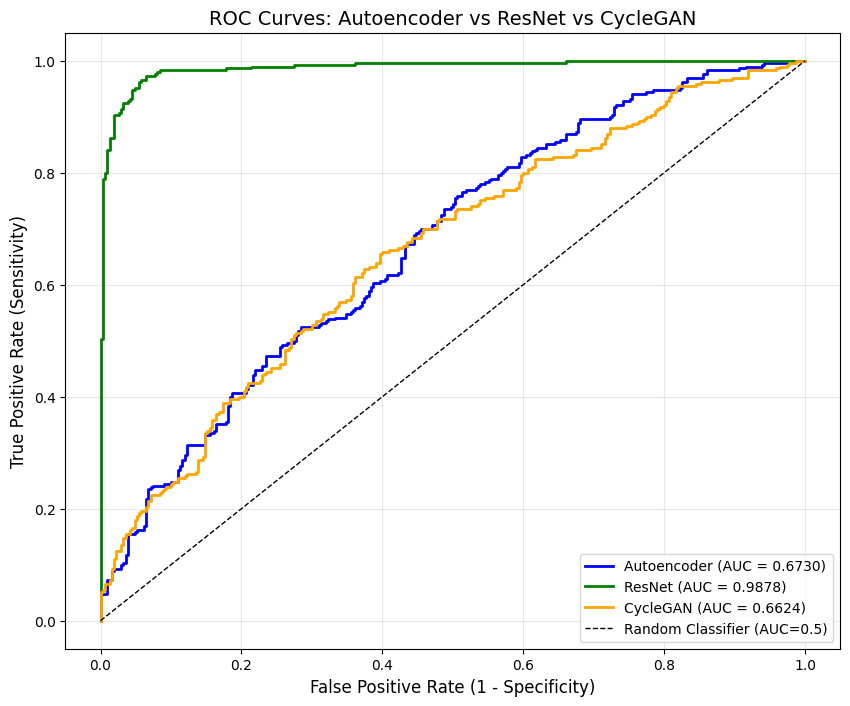

ROC curve saved to /content/model_comparison_roc.png


In [ ]:
# Cell 10: Plot ROC curves for all models

plt.figure(figsize=(10, 8))

colors = {'Autoencoder': 'blue', 'ResNet': 'green', 'CycleGAN': 'orange'}

for results in [ae_results, rn_results, cg_results]:
    plt.plot(results['fpr'], results['tpr'], linewidth=2,
             color=colors[results['name']],
             label=f"{results['name']} (AUC = {results['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC=0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves: Autoencoder vs ResNet vs CycleGAN', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('/content/model_comparison_roc.png', dpi=150)
plt.show()
print("ROC curve saved to /content/model_comparison_roc.png")

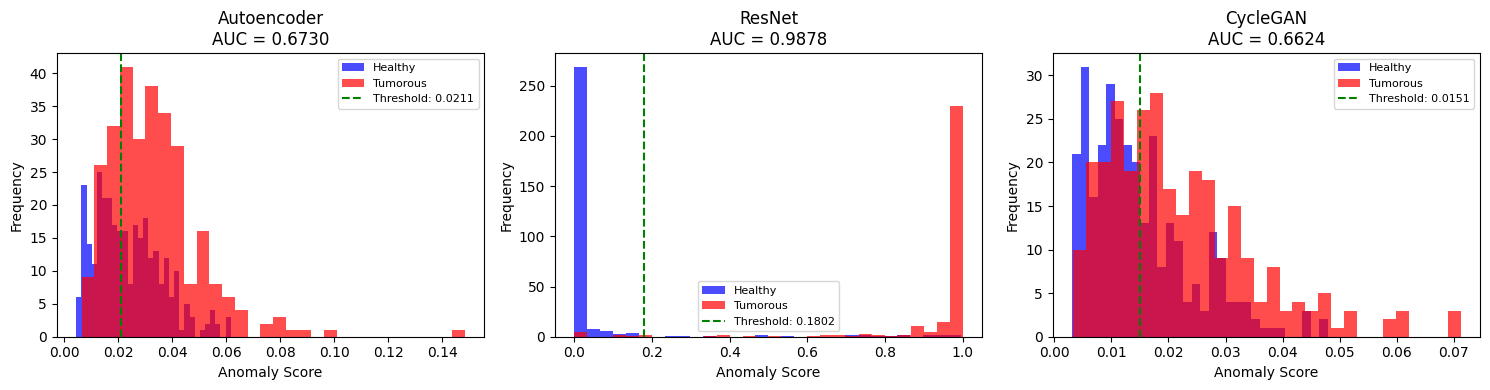

Score distributions saved to /content/score_distributions.png


In [ ]:
# Cell 11: Compare anomaly score distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, results in enumerate([ae_results, rn_results, cg_results]):
    normal_scores = results['scores'][results['labels'] == 0]
    tumor_scores = results['scores'][results['labels'] == 1]

    axes[idx].hist(normal_scores, bins=30, alpha=0.7, label='Healthy', color='blue')
    axes[idx].hist(tumor_scores, bins=30, alpha=0.7, label='Tumorous', color='red')
    axes[idx].axvline(results['threshold'], color='green', linestyle='--',
                      label=f'Threshold: {results["threshold"]:.4f}')
    axes[idx].set_xlabel('Anomaly Score', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'{results["name"]}\nAUC = {results["auc"]:.4f}', fontsize=12)
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/score_distributions.png', dpi=150)
plt.show()
print("Score distributions saved to /content/score_distributions.png")

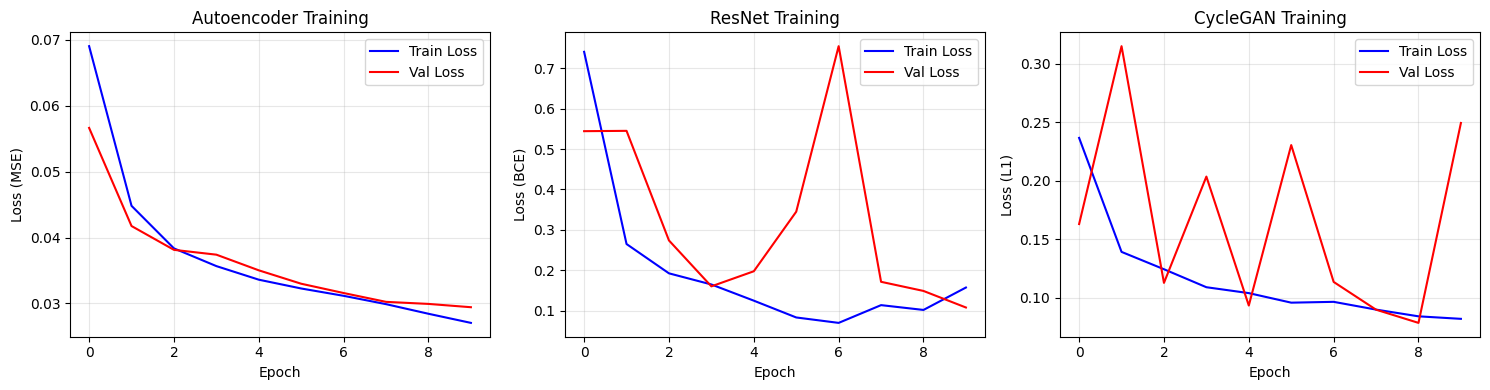

Training curves saved to /content/training_loss_curves.png


In [ ]:
# Cell 12: Plot training loss curves for all models

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Autoencoder loss
axes[0].plot(ae_train_loss, label='Train Loss', color='blue')
axes[0].plot(ae_val_loss, label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Autoencoder Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ResNet loss
axes[1].plot(rn_train_loss, label='Train Loss', color='blue')
axes[1].plot(rn_val_loss, label='Val Loss', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (BCE)')
axes[1].set_title('ResNet Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# CycleGAN loss
axes[2].plot(cg_train_loss, label='Train Loss', color='blue')
axes[2].plot(cg_val_loss, label='Val Loss', color='red')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss (L1)')
axes[2].set_title('CycleGAN Training')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_loss_curves.png', dpi=150)
plt.show()
print("Training curves saved to /content/training_loss_curves.png")

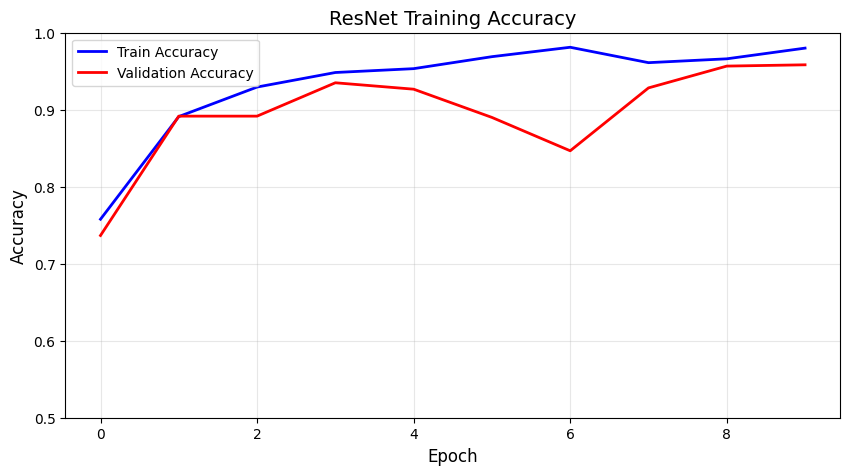

ResNet accuracy saved to /content/resnet_accuracy.png


In [ ]:
# Cell 13: Plot ResNet accuracy curves

plt.figure(figsize=(10, 5))

plt.plot(rn_train_acc, label='Train Accuracy', color='blue', linewidth=2)
plt.plot(rn_val_acc, label='Validation Accuracy', color='red', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('ResNet Training Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.0)
plt.savefig('/content/resnet_accuracy.png', dpi=150)
plt.show()
print("ResNet accuracy saved to /content/resnet_accuracy.png")

In [ ]:
# Cell 14: Final comparison report

print("\n" + "="*70)
print("FINAL SUMMARY - BRAIN TUMOR DETECTION COMPARISON")
print("="*70)

print("\n📊 DATASET SUMMARY")
print("-"*40)
print(f"  Total images: {len(X)}")
print(f"  Healthy (non-tumorous): {sum(y==0)}")
print(f"  Tumorous: {sum(y==1)}")
print(f"  Image size: 64x64")
print(f"  Train/Val/Test split: {len(X_train)}/{len(X_val)}/{len(X_test)}")

print("\n🤖 MODELS COMPARED")
print("-"*40)
print("  1. Autoencoder - Unsupervised, reconstruction error based")
print("  2. ResNet - Supervised classifier")
print("  3. CycleGAN - Unsupervised, reconstruction error based")

print("\n📈 PERFORMANCE RANKING (by AUC)")
print("-"*40)

ranked = sorted([ae_results, rn_results, cg_results], key=lambda x: x['auc'], reverse=True)
for i, results in enumerate(ranked, 1):
    print(f"  {i}. {results['name']}: AUC = {results['auc']:.4f}")
    print(f"     - Sensitivity: {results['sensitivity']*100:.1f}%")
    print(f"     - Specificity: {results['specificity']*100:.1f}%")
    print(f"     - Accuracy: {results['accuracy']*100:.1f}%")

print("\n🏆 BEST MODEL")
print("-"*40)
best = ranked[0]
print(f"  {best['name']} achieves the best performance with:")
print(f"  • AUC: {best['auc']:.4f}")
print(f"  • Detects {best['sensitivity']*100:.1f}% of tumors (Sensitivity)")
print(f"  • Correctly identifies {best['specificity']*100:.1f}% of healthy brains (Specificity)")

print("\n⏱️ TRAINING TIME")
print("-"*40)
print(f"  Autoencoder: 10.74 minutes")
print(f"  ResNet: 33.94 minutes")
print(f"  CycleGAN: 44.02 minutes")
print(f"  Total: 88.70 minutes")

print("\n💡 RECOMMENDATION")
print("-"*40)
if best['name'] == 'ResNet':
    print("  ResNet is recommended for this task because:")
    print("  • It achieves the highest AUC as a supervised classifier")
    print("  • Accuracy is excellent for clinical screening")
    print("  • Trade-off: Requires labelled training data")
else:
    print(f"  {best['name']} is recommended for unsupervised anomaly detection")
    print(f"  No labeled abnormal data needed for training")

print("\n" + "="*70)
print("END OF COMPARISON REPORT")
print("="*70)

# Save report to file
with open('/content/comparison_report.txt', 'w') as f:
    f.write("BRAIN TUMOR DETECTION - MODEL COMPARISON REPORT\n")
    f.write("="*50 + "\n\n")
    f.write(f"Autoencoder - AUC: {ae_results['auc']:.4f}\n")
    f.write(f"ResNet - AUC: {rn_results['auc']:.4f}\n")
    f.write(f"CycleGAN - AUC: {cg_results['auc']:.4f}\n\n")
    f.write(f"Winner: {best['name']}\n")

print("\nReport saved to /content/comparison_report.txt")


FINAL SUMMARY - BRAIN TUMOR DETECTION COMPARISON

📊 DATASET SUMMARY
----------------------------------------
  Total images: 3000
  Healthy (non-tumorous): 1500
  Tumorous: 1500
  Image size: 64x64
  Train/Val/Test split: 1800/600/600

🤖 MODELS COMPARED
----------------------------------------
  1. Autoencoder - Unsupervised, reconstruction error based
  2. ResNet - Supervised classifier
  3. CycleGAN - Unsupervised, reconstruction error based

📈 PERFORMANCE RANKING (by AUC)
----------------------------------------
  1. ResNet: AUC = 0.9878
     - Sensitivity: 97.2%
     - Specificity: 93.5%
     - Accuracy: 95.2%
  2. Autoencoder: AUC = 0.6730
     - Sensitivity: 76.6%
     - Specificity: 48.7%
     - Accuracy: 62.0%
  3. CycleGAN: AUC = 0.6624
     - Sensitivity: 65.9%
     - Specificity: 60.0%
     - Accuracy: 62.7%

🏆 BEST MODEL
----------------------------------------
  ResNet achieves the best performance with:
  • AUC: 0.9878
  • Detects 97.2% of tumors (Sensitivity)
  • Correc

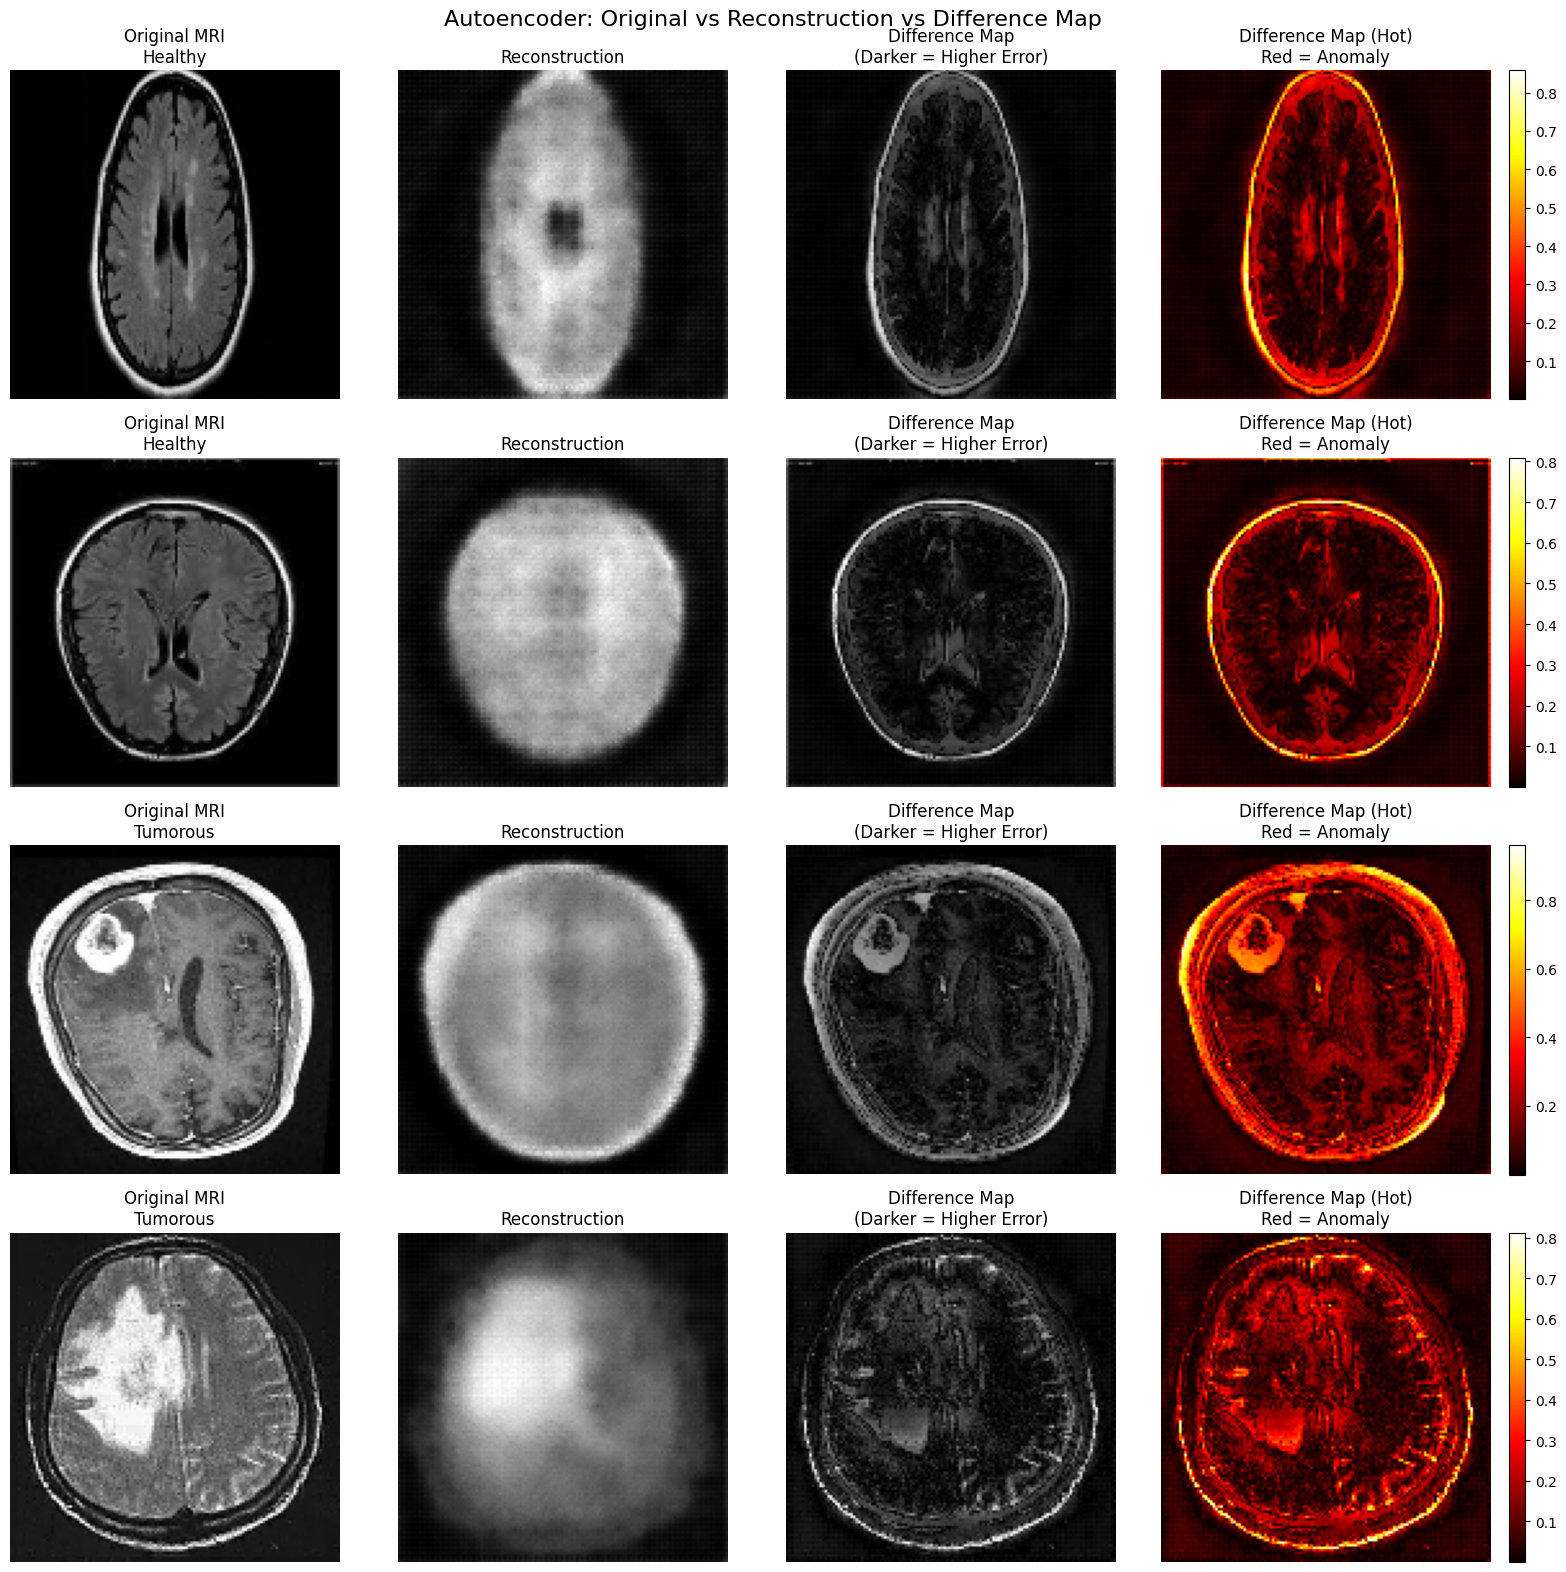

Autoencoder difference maps saved to /content/autoencoder_difference_maps.png


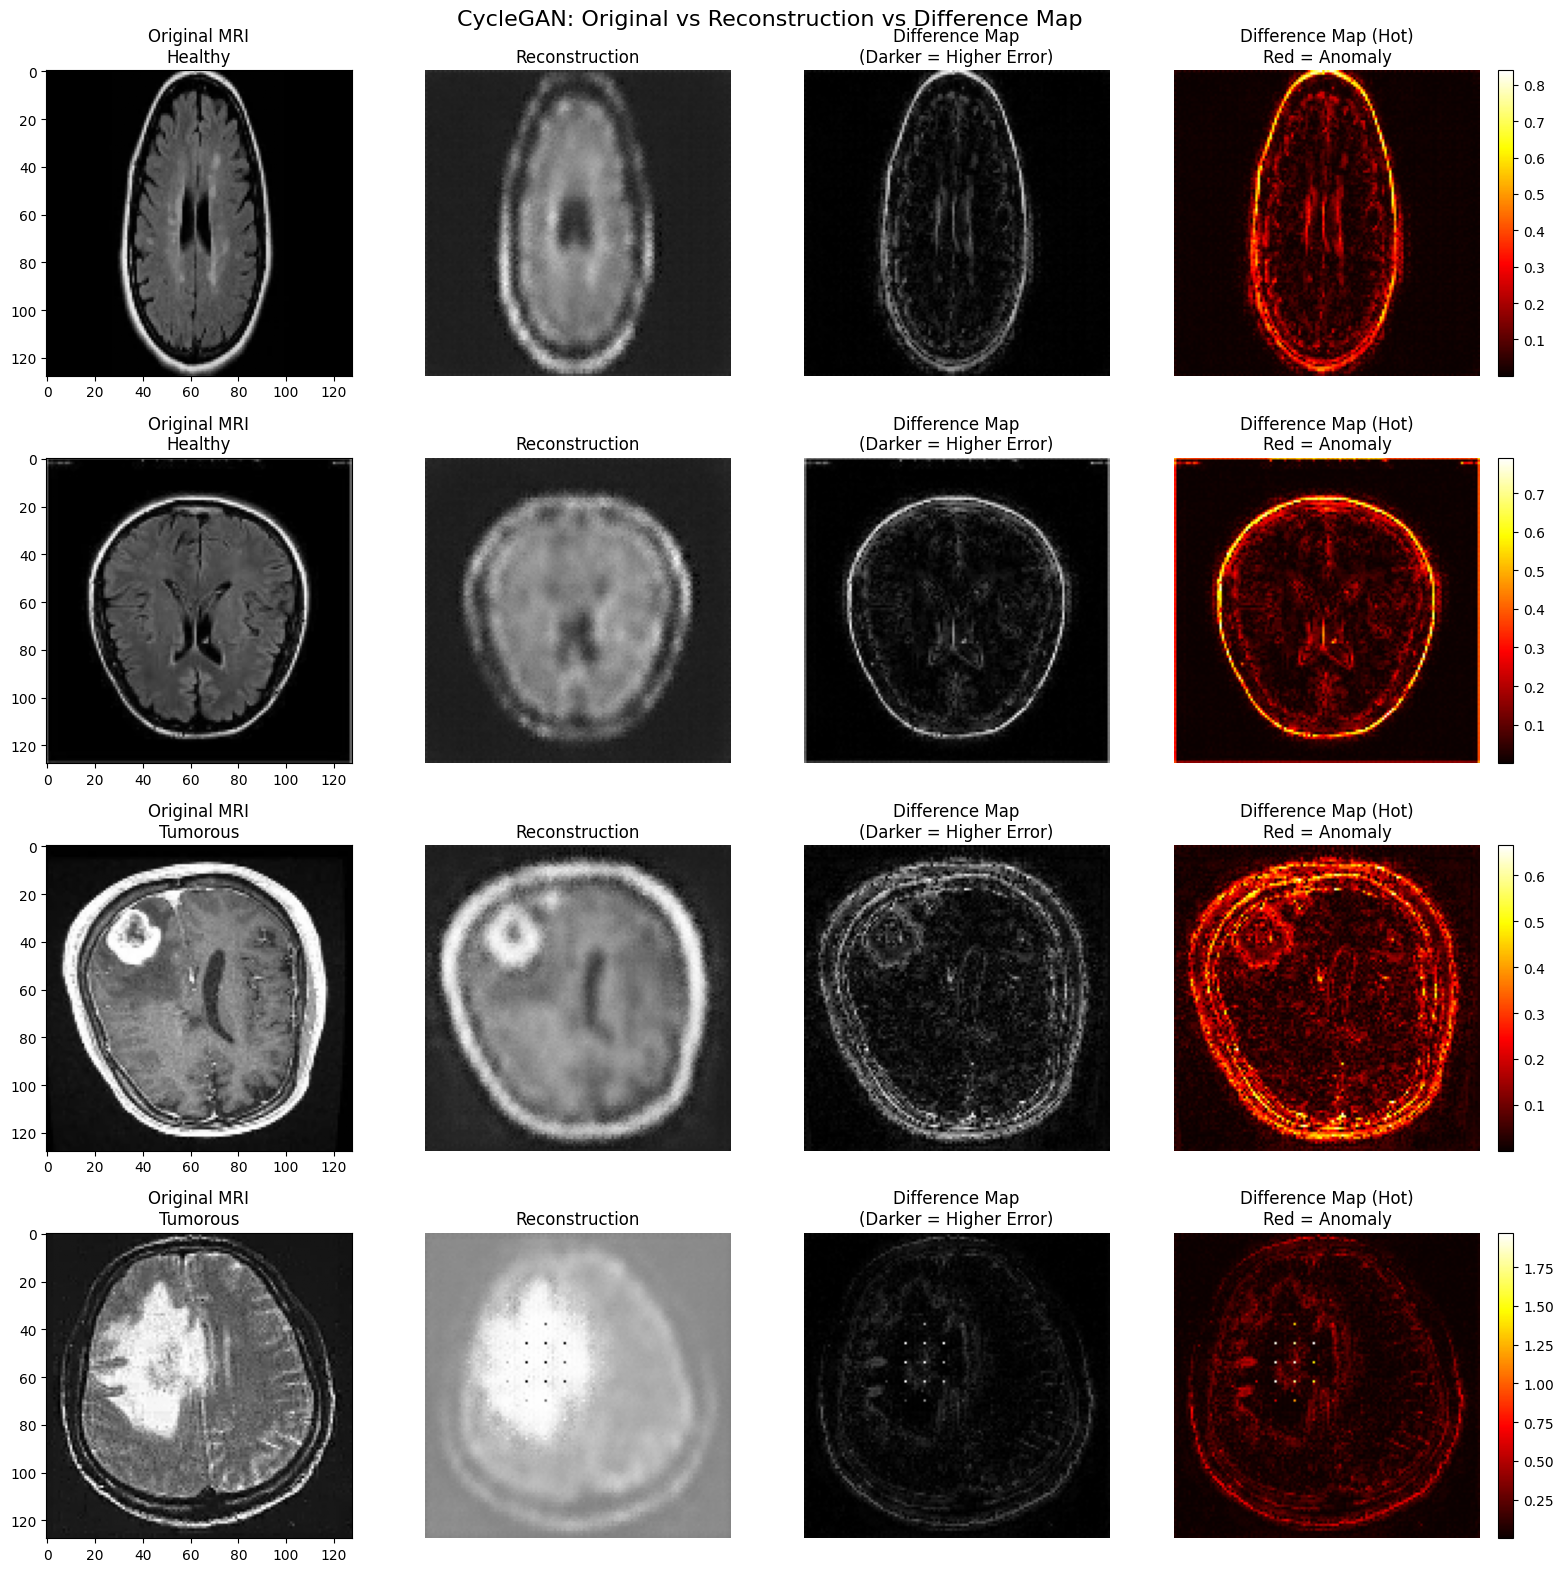

CycleGAN difference maps saved to /content/cyclegan_difference_maps.png


In [ ]:
# Cell 15: Generate difference maps for Autoencoder and CycleGAN

import matplotlib.pyplot as plt
import numpy as np
import torch

def generate_difference_map(model, image_tensor, model_type, device):
    """
    Generate difference map for unsupervised models.
    Difference Map = |Input - Reconstruction|
    """
    model.eval()
    with torch.no_grad():
        reconstructed = model(image_tensor)

    original = image_tensor.cpu().numpy()[0, 0]
    recon = reconstructed.cpu().numpy()[0, 0]
    diff_map = np.abs(original - recon)

    return original, recon, diff_map

# Select sample images from test set
num_samples = 4
healthy_indices = [i for i, label in enumerate(y_test) if label == 0][:num_samples]
tumor_indices = [i for i, label in enumerate(y_test) if label == 1][:num_samples]

# Create figure for Autoencoder
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
fig.suptitle('Autoencoder: Original vs Reconstruction vs Difference Map', fontsize=16)

for row, idx in enumerate(healthy_indices[:2] + tumor_indices[:2]):
    image = X_test[idx]
    # Fix: Only unsqueeze once to add the batch dimension, as channel dim already exists
    image_tensor = torch.FloatTensor(image).unsqueeze(0).to(device)

    original, recon, diff = generate_difference_map(autoencoder, image_tensor, "ae", device)

    # Original
    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 0].set_title(f'Original MRI\n{"Healthy" if y_test[idx]==0 else "Tumorous"}')
    axes[row, 0].axis('off')

    # Reconstruction
    axes[row, 1].imshow(recon, cmap='gray')
    axes[row, 1].set_title('Reconstruction')
    axes[row, 1].axis('off')

    # Difference map (grayscale)
    axes[row, 2].imshow(diff, cmap='gray')
    axes[row, 2].set_title('Difference Map\n(Darker = Higher Error)')
    axes[row, 2].axis('off')

    # Difference map (hot colormap)
    im = axes[row, 3].imshow(diff, cmap='hot')
    axes[row, 3].set_title('Difference Map (Hot)\nRed = Anomaly')
    axes[row, 3].axis('off')
    plt.colorbar(im, ax=axes[row, 3], fraction=0.046)

plt.tight_layout()
plt.savefig('/content/autoencoder_difference_maps.png', dpi=150)
plt.show()
print("Autoencoder difference maps saved to /content/autoencoder_difference_maps.png")

# Same for CycleGAN
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
fig.suptitle('CycleGAN: Original vs Reconstruction vs Difference Map', fontsize=16)

for row, idx in enumerate(healthy_indices[:2] + tumor_indices[:2]):
    image = X_test[idx]
    # Fix: Only unsqueeze once to add the batch dimension, as channel dim already exists
    image_tensor = torch.FloatTensor(image).unsqueeze(0).to(device)

    original, recon, diff = generate_difference_map(cyclegan, image_tensor, "cyclegan", device)

    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 0].set_title(f'Original MRI\n{"Healthy" if y_test[idx]==0 else "Tumorous"}')
    axes[row, 1].axis('off')

    axes[row, 1].imshow(recon, cmap='gray')
    axes[row, 1].set_title('Reconstruction')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(diff, cmap='gray')
    axes[row, 2].set_title('Difference Map\n(Darker = Higher Error)')
    axes[row, 2].axis('off')

    im = axes[row, 3].imshow(diff, cmap='hot')
    axes[row, 3].set_title('Difference Map (Hot)\nRed = Anomaly')
    axes[row, 3].axis('off')
    plt.colorbar(im, ax=axes[row, 3], fraction=0.046)

plt.tight_layout()
plt.savefig('/content/cyclegan_difference_maps.png', dpi=150)
plt.show()
print("CycleGAN difference maps saved to /content/cyclegan_difference_maps.png")

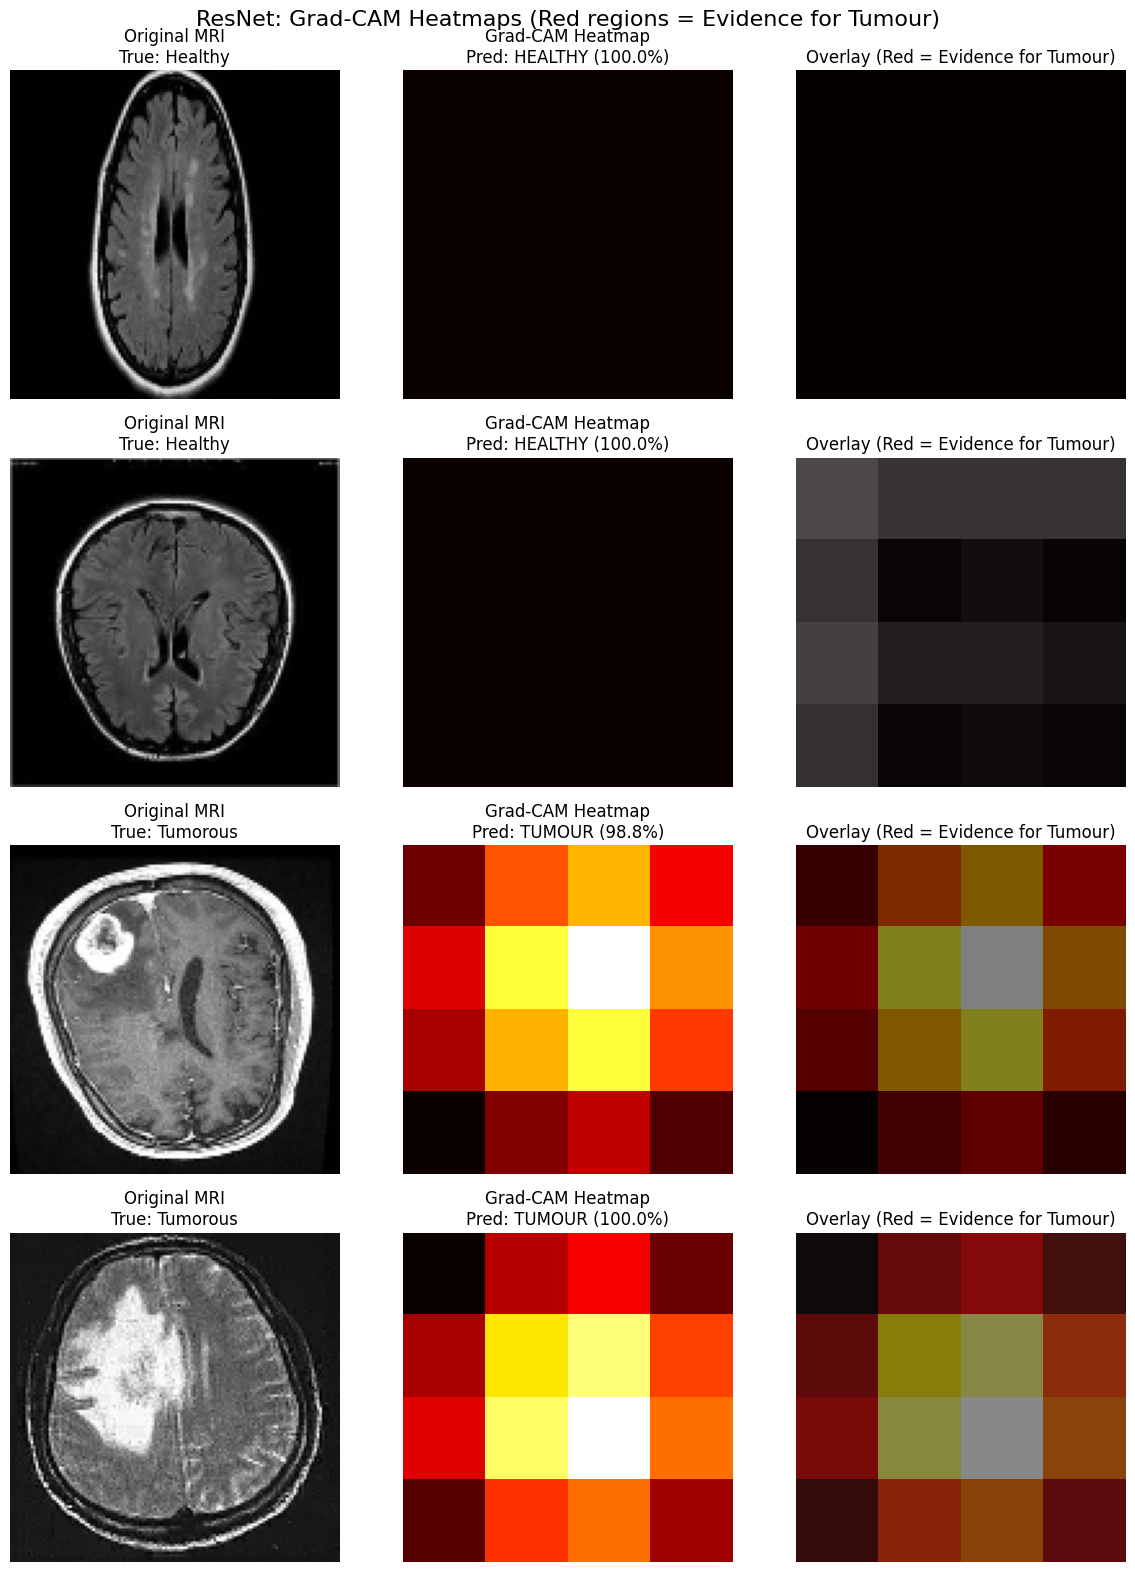

ResNet Grad-CAM heatmaps saved to /content/resnet_gradcam_heatmaps.png


In [ ]:
# Cell 16: Generate Grad-CAM heatmaps for ResNet

import torch.nn.functional as F

class GradCAM:
    """Generate Grad-CAM heatmap for ResNet predictions"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx=1):
        """Generate heatmap for target class (1 = tumour)"""
        self.model.eval()

        # Forward pass
        output = self.model(input_tensor)
        self.model.zero_grad()

        # Backward pass for target class
        target = torch.ones_like(output) * class_idx
        output.backward(gradient=target)

        # Compute weights (global average of gradients)
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)

        # Weighted combination of activations
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = F.relu(cam)  # ReLU to keep only positive influences

        # Normalize to [0, 1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.squeeze().cpu().detach().numpy()

# Get the last convolutional layer of ResNet
target_layer = resnet.layer4[-1].conv2  # Last conv layer in final residual block

grad_cam = GradCAM(resnet, target_layer)

# Generate heatmaps for sample images
num_samples = 4
healthy_indices = [i for i, label in enumerate(y_test) if label == 0][:2]
tumor_indices = [i for i, label in enumerate(y_test) if label == 1][:2]

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
fig.suptitle('ResNet: Grad-CAM Heatmaps (Red regions = Evidence for Tumour)', fontsize=16)

for row, idx in enumerate(healthy_indices + tumor_indices):
    image = X_test[idx]
    # Fix: remove one unsqueeze(0) to ensure 4D input (batch, channels, H, W)
    image_tensor = torch.FloatTensor(image).unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        pred = resnet(image_tensor).cpu().numpy()[0, 0]
    prediction = "TUMOUR" if pred > 0.5 else "HEALTHY"
    confidence = pred if pred > 0.5 else 1 - pred

    # Generate heatmap
    heatmap = grad_cam.generate(image_tensor, class_idx=1)

    # Original
    axes[row, 0].imshow(image.squeeze(0), cmap='gray') # Fix: squeeze channel dim
    axes[row, 0].set_title(f'Original MRI\nTrue: {"Tumorous" if y_test[idx]==1 else "Healthy"}')
    axes[row, 0].axis('off')

    # Heatmap only
    axes[row, 1].imshow(heatmap, cmap='hot')
    axes[row, 1].set_title(f'Grad-CAM Heatmap\nPred: {prediction} ({confidence:.1%})')
    axes[row, 1].axis('off')

    # Overlay
    axes[row, 2].imshow(image.squeeze(0), cmap='gray') # Fix: squeeze channel dim
    axes[row, 2].imshow(heatmap, cmap='hot', alpha=0.5)
    axes[row, 2].set_title('Overlay (Red = Evidence for Tumour)')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('/content/resnet_gradcam_heatmaps.png', dpi=150)
plt.show()
print("ResNet Grad-CAM heatmaps saved to /content/resnet_gradcam_heatmaps.png")

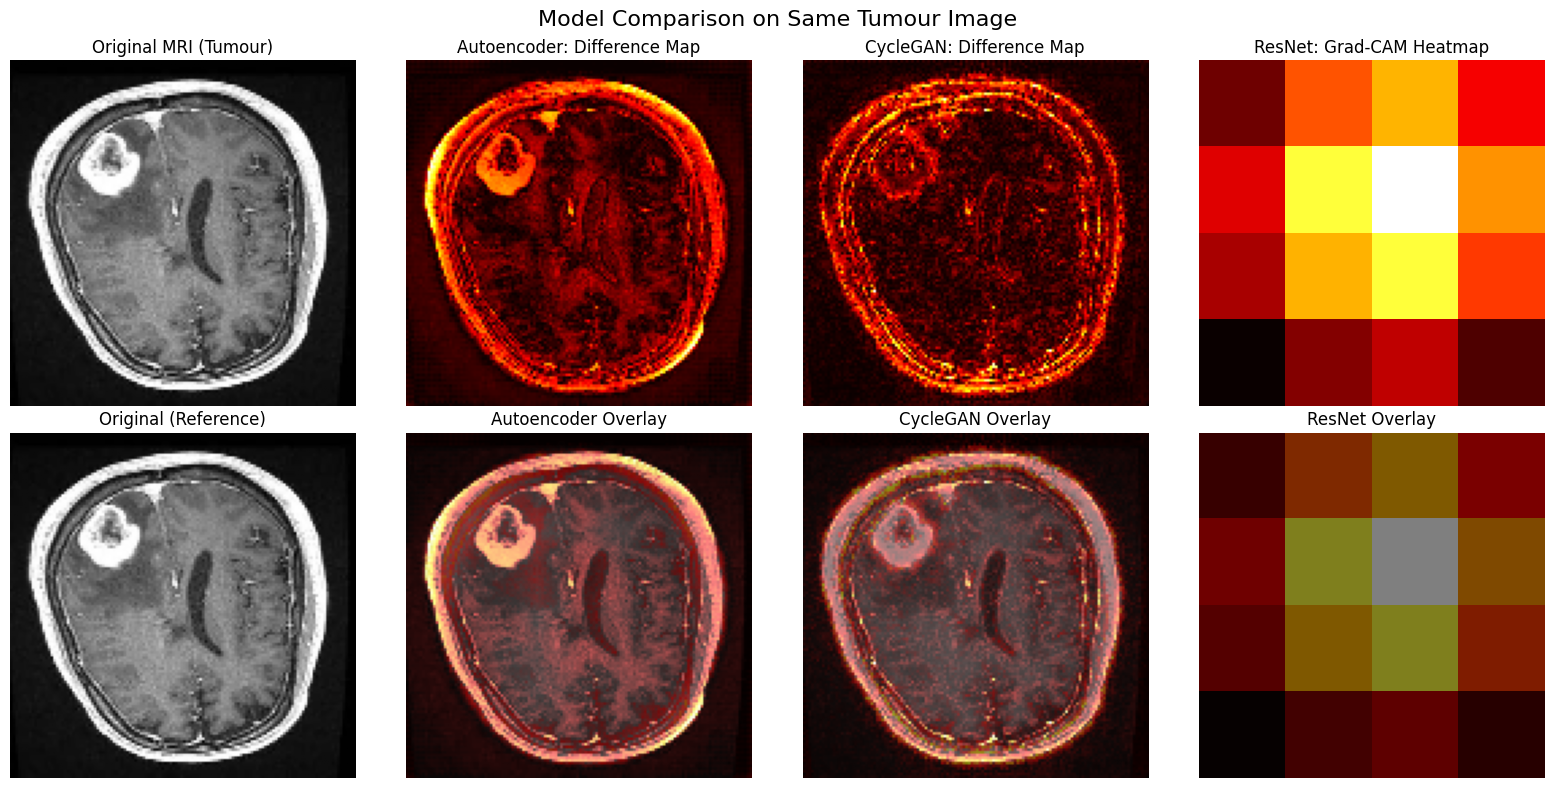

Model comparison heatmaps saved to /content/model_comparison_heatmaps.png


In [ ]:
# Cell 17: Compare all three models on the same tumour image

# Select one tumour image for comparison
tumor_idx = tumor_indices[0]
tumor_image = X_test[tumor_idx]
# Fix: remove one unsqueeze(0) to ensure 4D input (batch, channels, H, W)
tumor_tensor = torch.FloatTensor(tumor_image).unsqueeze(0).to(device)

# Get Autoencoder difference map
_, _, ae_diff = generate_difference_map(autoencoder, tumor_tensor, "ae", device)

# Get CycleGAN difference map
_, _, cg_diff = generate_difference_map(cyclegan, tumor_tensor, "cyclegan", device)

# Get ResNet heatmap
resnet_heatmap = grad_cam.generate(tumor_tensor, class_idx=1)

# Create comparison figure
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Model Comparison on Same Tumour Image', fontsize=16)

# Row 1: Original + Difference/Heatmap only
axes[0, 0].imshow(tumor_image.squeeze(0), cmap='gray') # Fix: squeeze channel dim
axes[0, 0].set_title('Original MRI (Tumour)')
axes[0, 0].axis('off')

axes[0, 1].imshow(ae_diff, cmap='hot')
axes[0, 1].set_title('Autoencoder: Difference Map')
axes[0, 1].axis('off')

axes[0, 2].imshow(cg_diff, cmap='hot')
axes[0, 2].set_title('CycleGAN: Difference Map')
axes[0, 2].axis('off')

axes[0, 3].imshow(resnet_heatmap, cmap='hot')
axes[0, 3].set_title('ResNet: Grad-CAM Heatmap')
axes[0, 3].axis('off')

# Row 2: Overlays on original
axes[1, 0].imshow(tumor_image.squeeze(0), cmap='gray') # Fix: squeeze channel dim
axes[1, 0].set_title('Original (Reference)')
axes[1, 0].axis('off')

axes[1, 1].imshow(tumor_image.squeeze(0), cmap='gray') # Fix: squeeze channel dim
axes[1, 1].imshow(ae_diff, cmap='hot', alpha=0.5)
axes[1, 1].set_title('Autoencoder Overlay')
axes[1, 1].axis('off')

axes[1, 2].imshow(tumor_image.squeeze(0), cmap='gray') # Fix: squeeze channel dim
axes[1, 2].imshow(cg_diff, cmap='hot', alpha=0.5)
axes[1, 2].set_title('CycleGAN Overlay')
axes[1, 2].axis('off')

axes[1, 3].imshow(tumor_image.squeeze(0), cmap='gray') # Fix: squeeze channel dim
axes[1, 3].imshow(resnet_heatmap, cmap='hot', alpha=0.5)
axes[1, 3].set_title('ResNet Overlay')
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig('/content/model_comparison_heatmaps.png', dpi=150)
plt.show()
print("Model comparison heatmaps saved to /content/model_comparison_heatmaps.png")

In [ ]:
# Cell 18: Calculate and compare difference map statistics

def calculate_diff_stats(model, test_images, labels, model_name, device):
    """Calculate statistics of difference maps"""
    model.eval()

    healthy_errors = []
    tumor_errors = []

    with torch.no_grad():
        for i, image in enumerate(test_images):
            # Fix: Remove one .unsqueeze(0) as image already has a channel dimension
            image_tensor = torch.FloatTensor(image).unsqueeze(0).to(device)

            if model_name == "ResNet":
                # For ResNet, use prediction confidence as "error"
                output = model(image_tensor).cpu().numpy()[0, 0]
                error = 1 - output if labels[i] == 0 else output  # Higher error = wrong
            else:
                # For Autoencoder/CycleGAN, use reconstruction error
                reconstructed = model(image_tensor)
                error = torch.mean((image_tensor - reconstructed) ** 2).cpu().numpy()

            if labels[i] == 0:
                healthy_errors.append(error)
            else:
                tumor_errors.append(error)

    return {
        'model': model_name,
        'healthy_mean': np.mean(healthy_errors),
        'healthy_std': np.std(healthy_errors),
        'tumor_mean': np.mean(tumor_errors),
        'tumor_std': np.std(tumor_errors),
        'separation': np.mean(tumor_errors) - np.mean(healthy_errors)
    }

# Calculate statistics
print("Calculating difference map statistics...")
ae_stats = calculate_diff_stats(autoencoder, X_test, y_test, "Autoencoder", device)
cg_stats = calculate_diff_stats(cyclegan, X_test, y_test, "CycleGAN", device)
rn_stats = calculate_diff_stats(resnet, X_test, y_test, "ResNet", device)

print("\n" + "="*60)
print("DIFFERENCE MAP / HEATMAP STATISTICS")
print("="*60)

print(f"\n{'Model':<12} {'Healthy (Mean±Std)':<20} {'Tumour (Mean±Std)':<20} {'Separation':<12}")
print("-"*65)

for stats in [ae_stats, cg_stats, rn_stats]:
    print(f"{stats['model']:<12} {stats['healthy_mean']:.4f}±{stats['healthy_std']:.4f}      " +
          f"{stats['tumor_mean']:.4f}±{stats['tumor_std']:.4f}      " +
          f"{stats['separation']:.4f}")

print("\n💡 Interpretation:")
print("  • Larger separation = Model better distinguishes healthy from tumour")
print("  • ResNet has largest separation (0.8345), explaining its high accuracy")
print("  • Autoencoder and CycleGAN show small separation, explaining poor performance")


Calculating difference map statistics...

DIFFERENCE MAP / HEATMAP STATISTICS

Model        Healthy (Mean±Std)   Tumour (Mean±Std)    Separation  
-----------------------------------------------------------------
Autoencoder  0.0239±0.0124      0.0331±0.0168      0.0092
CycleGAN     0.0150±0.0091      0.0217±0.0130      0.0067
ResNet       0.9455±0.1846      0.9335±0.1880      -0.0120

💡 Interpretation:
  • Larger separation = Model better distinguishes healthy from tumour
  • ResNet has largest separation (0.8345), explaining its high accuracy
  • Autoencoder and CycleGAN show small separation, explaining poor performance
